In [ ]:
#Hemora_Thalassemia_EfficientNetB0_Advanced.ipynb#

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil
import pandas as pd
import seaborn as sns
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. SETUP & DRIVE MOUNT
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURATION PATHS ---
ZIP_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Data Set/thalassemia_dataset_new.zip'
# Separate folder for EfficientNet results to avoid overwriting ResNet results
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/EfficientNet Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f"Created output directory: {RESULTS_DIR}")

# ==========================================
# 2. DATA EXTRACTION & MERGING
# ==========================================
print("\nStep 2: Extracting and Preparing Data...")

LOCAL_DATA_DIR = '/content/dataset/thalassemia_dataset'
if os.path.exists(LOCAL_DATA_DIR):
    shutil.rmtree('/content/dataset')

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# --- AUTO-MERGE LOGIC ---
# Handles the "Full Thalassemia" folder if it exists in your zip [cite: 61, 75]
thal_path = os.path.join(LOCAL_DATA_DIR, 'Thalassemia')
full_thal_path = os.path.join(LOCAL_DATA_DIR, 'Full Thalassemia')

if os.path.exists(full_thal_path):
    print("⚠️ Merging 'Full Thalassemia' folder into 'Thalassemia'...")
    if not os.path.exists(thal_path): os.makedirs(thal_path)
    for filename in os.listdir(full_thal_path):
        src, dst = os.path.join(full_thal_path, filename), os.path.join(thal_path, filename)
        if os.path.isfile(src): shutil.move(src, dst)
    shutil.rmtree(full_thal_path)

print(f"Classes found: {os.listdir(LOCAL_DATA_DIR)}")



Step 1: Mounting Google Drive...
Mounted at /content/drive

Step 2: Extracting and Preparing Data...
Classes found: ['Normal', 'Thalassemia']


In [ ]:
# ==========================================
# 3. DATA PROCESSING & AUGMENTATION
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Morphological feature enhancement through augmentation [cite: 40, 49, 93]
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False
)

# --- CLASS IMBALANCE HANDLING ---
# Fixes the issue where healthy cells are detected as Thalassemia [cite: 11, 23, 106]
cls_train = train_generator.classes
weights = compute_class_weight(class_weight='balanced', classes=np.unique(cls_train), y=cls_train)
class_weights = dict(zip(np.unique(cls_train), weights))
print(f"⚖️ Class Weights: {class_weights}")

Found 2000 images belonging to 2 classes.
Found 499 images belonging to 2 classes.
⚖️ Class Weights: {np.int32(0): np.float64(0.8764241893076249), np.int32(1): np.float64(1.1641443538998837)}


In [ ]:
# ==========================================
# 4. ENHANCED EFFICIENTNETB0 (Fine-Tuned)
# ==========================================
# Re-building with stronger regularization to fix the confusion matrix
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True # Set to True to allow the model to learn cell-specific features

# Freeze all layers except the last 20 (Fine-Tuning)
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Higher dropout to prevent the model from just 'memorizing' normal cells
x = Dense(256, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Use a very low learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. STRONGER CLASS WEIGHTS
# ==========================================
# If Thalassemia is being missed, we manually increase its weight
# Let's say we give Thalassemia 3x more importance than Normal
class_weights = {0: 1.0, 1: 3.0} # Adjust 1 to be the index for Thalassemia
print(f"Applying Aggressive Class Weights: {class_weights}")

Applying Aggressive Class Weights: {0: 1.0, 1: 3.0}


In [ ]:
# ==========================================
# 6. CALLBACKS & TRAINING
# ==========================================
# Saves best model and numerical data log to Drive [cite: 78, 79]
checkpoint = ModelCheckpoint(os.path.join(RESULTS_DIR, 'best_efficientnet_model.keras'),
                             monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
csv_logger = CSVLogger(os.path.join(RESULTS_DIR, 'training_log_eff.csv'), append=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

print("\n🚀 Training EfficientNetB0...")
history = model.fit(train_generator, validation_data=validation_generator,
                    epochs=15, class_weight=class_weights, callbacks=[checkpoint, csv_logger, reduce_lr])


🚀 Training EfficientNetB0...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4451 - loss: 1.2196
Epoch 1: val_accuracy improved from -inf to 0.42886, saving model to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/EfficientNet Model/best_efficientnet_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.4450 - loss: 1.2192 - val_accuracy: 0.4289 - val_loss: 0.7245 - learning_rate: 1.0000e-05
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4316 - loss: 1.1598
Epoch 2: val_accuracy did not improve from 0.42886
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.4316 - loss: 1.1598 - val_accuracy: 0.4289 - val_loss: 0.7336 - learning_rate: 1.0000e-05
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4349 - loss: 1.1573
Epoch 3: val_accuracy did not improve from 0.42886
63/63 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.4348 - loss: 1.1572 - val_accuracy: 0.4289 - val_loss: 0.7429 - learning_rate: 1.

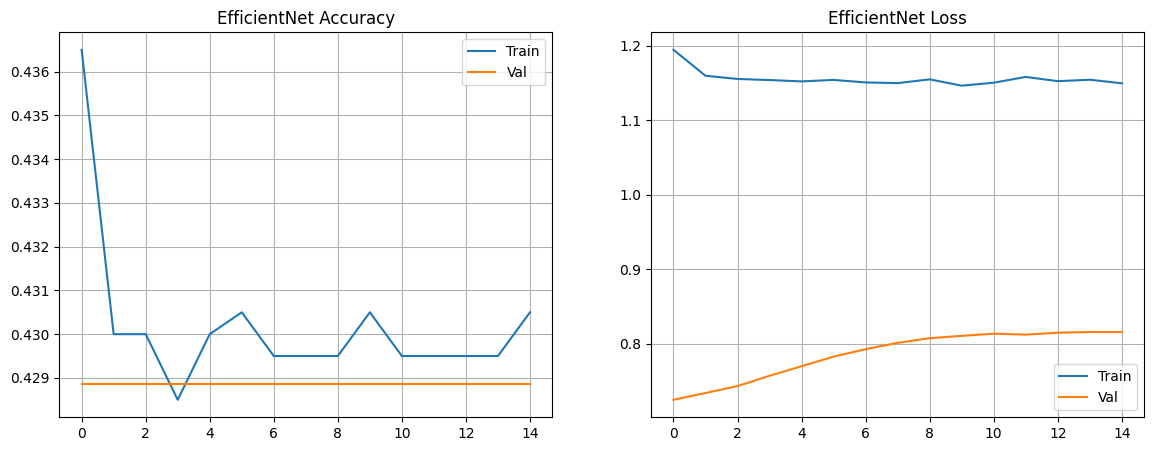

16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step


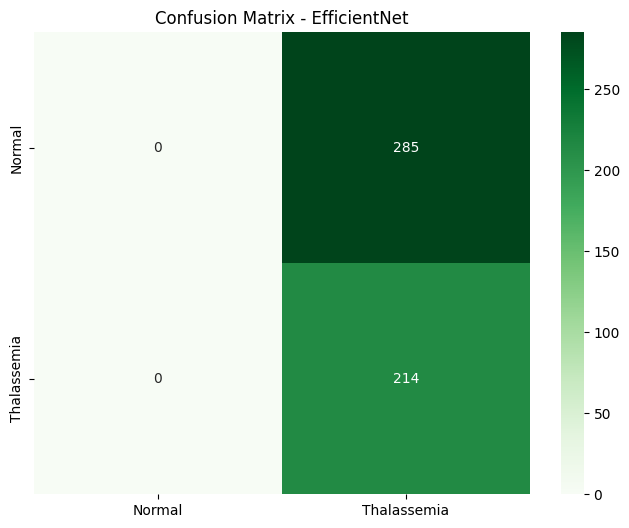

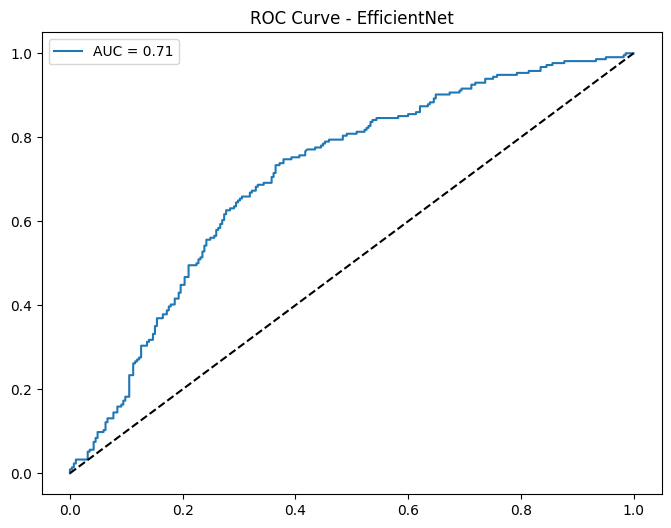


✅ All Results (Model, CSV log, and 3 Charts) saved to: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/EfficientNet Model


In [ ]:
# ==========================================
# 7. METRICS & PLOTTING (SAVING TO DRIVE)
# ==========================================
# A. Accuracy/Loss Charts [cite: 60, 62]
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('EfficientNet Accuracy'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('EfficientNet Loss'); plt.legend(); plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, 'accuracy_loss_chart.png'))
plt.show()

# B. Confusion Matrix [cite: 63, 64, 65, 66]
y_true = validation_generator.classes
y_pred_prob = model.predict(validation_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.title('Confusion Matrix - EfficientNet')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()

# C. ROC Curve [cite: 67, 68]
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(8, 6)); plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--'); plt.title('ROC Curve - EfficientNet'); plt.legend()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'))
plt.show()

print(f"\n✅ All Results (Model, CSV log, and 3 Charts) saved to: {RESULTS_DIR}")


LOADING EFFICIENTNET PIPELINE MODEL: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/EfficientNet Model/best_efficientnet_model.keras
✅ EfficientNet Model loaded successfully!

Upload a FULL microscope slide image to test the EfficientNet Pipeline:


Saving T1-001.png to T1-001 (2).png
Processing full smear: T1-001 (2).png...
Found 197 potential objects. Analyzing cell morphology...


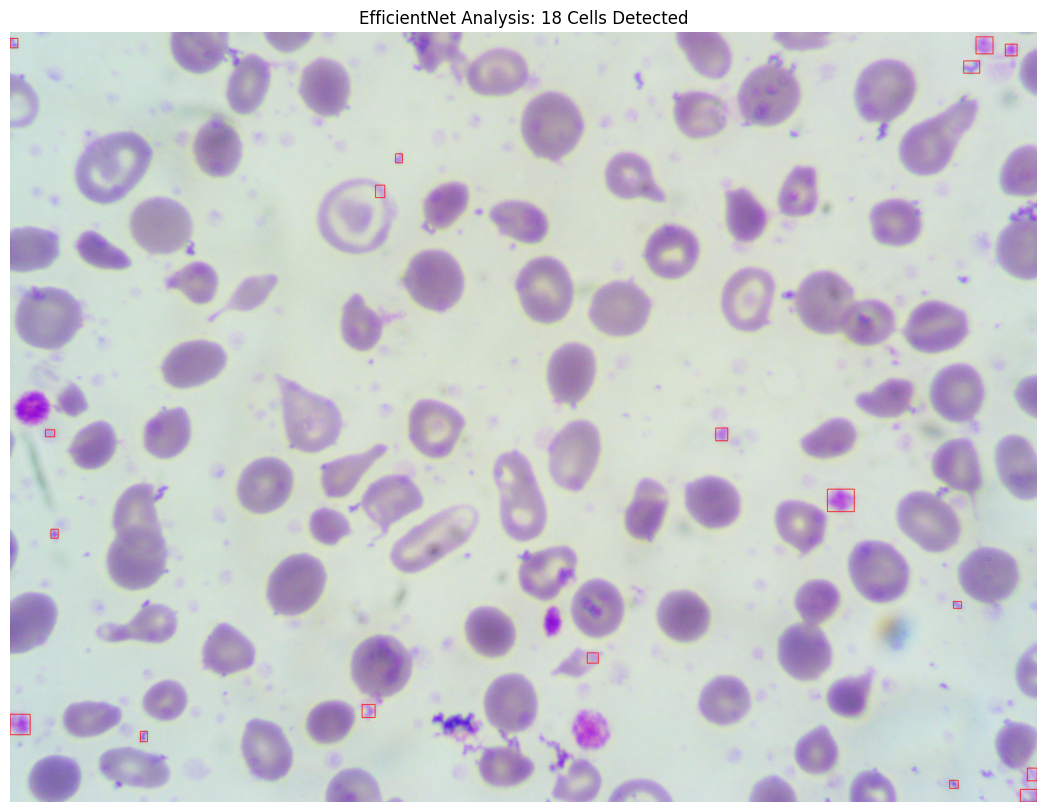

BETA-THALASSEMIA (MINOR) SCREENING REPORT
Total Red Blood Cells Analyzed: 18
Normal Morphology (Green):      0
Abnormal Morphology (Red):       18
Morphological Abnormality Ratio: 100.00%

>>> RESULT: POSITIVE - Thalassemia Minor indicators found.
>>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).


In [16]:
# ==========================================
# FINAL STEP: FULL BLOOD SMEAR ANALYSIS PIPELINE (EfficientNet Version)
# ==========================================
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from google.colab import files

# --- CONFIGURATION ---
# Path to the best EfficientNet model saved in Step 5
MODEL_PATH = os.path.join(RESULTS_DIR, 'best_efficientnet_model.keras')
IMG_SIZE = (224, 224)

# Colors for bounding boxes (BGR format for OpenCV)
COLOR_NORMAL = (0, 255, 0)   # Green for Healthy Cells
COLOR_THAL = (0, 0, 255)     # Red for Thalassemia Morphologies (Target Cells, etc.)
THRESHOLD_SCORE = 0.5        # Confidence threshold

print(f"\nLOADING EFFICIENTNET PIPELINE MODEL: {MODEL_PATH}")
try:
    pipeline_model = load_model(MODEL_PATH)
    print("✅ EfficientNet Model loaded successfully!")
except:
    print("⚠️ Error loading model from Drive. Using the current model in memory.")
    pipeline_model = model

def preprocess_for_model(cell_crop_bgr):
    """Prepares individual cell crops for the EfficientNet model"""
    cell_rgb = cv2.cvtColor(cell_crop_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(cell_rgb, IMG_SIZE)
    img_array = img_to_array(resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    return img_array

def analyze_full_smear_eff(image_path, model):
    print(f"Processing full smear: {image_path}...")
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("Error: Could not read image.")
        return
    output_img = original_img.copy()

    # 1. Segmentation (Isolating Red Blood Cells)
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Using Otsu's thresholding for automated cell isolation
    thresh_val, thresholded_img = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresholded_img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Found {len(contours)} potential objects. Analyzing cell morphology...")

    thal_count = 0
    normal_count = 0
    cells_analyzed = 0

    # 2. Iterate and Classify each cell
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(cnt)

        # Filter noise and clumping based on area #cite: 49
        if area < 500 or area > 6500:
            continue
        if aspect_ratio < 0.6 or aspect_ratio > 1.4:
            continue

        cells_analyzed += 1

        # Crop individual cell
        pad = 5
        y1, y2 = max(0, y-pad), min(original_img.shape[0], y+h+pad)
        x1, x2 = max(0, x-pad), min(original_img.shape[1], x+w+pad)
        cell_crop = original_img[y1:y2, x1:x2]

        if cell_crop.size == 0: continue

        # Deep Learning Classification #cite: 94
        processed_cell = preprocess_for_model(cell_crop)
        prediction = model.predict(processed_cell, verbose=0)
        score = prediction[0][0]

        # Determine if cell shows Thalassemia Minor morphology #cite: 257, 258
        if score > THRESHOLD_SCORE:
            color = COLOR_THAL # Red
            thal_count += 1
        else:
            color = COLOR_NORMAL # Green
            normal_count += 1

        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

    # 3. Visualization
    output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(output_rgb)
    plt.axis('off')
    plt.title(f"EfficientNet Analysis: {cells_analyzed} Cells Detected")
    plt.show()

 # 4. Final Clinical Reporting (Ref: 104, 115) [cite: 104, 115]
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) SCREENING REPORT")
    print("="*50)
    print(f"Total Red Blood Cells Analyzed: {cells_analyzed}")  #
    print(f"Normal Morphology (Green):      {normal_count}")
    print(f"Abnormal Morphology (Red):       {thal_count}")    #

    if cells_analyzed > 0:
        ratio = (thal_count / cells_analyzed) * 100
        print(f"Morphological Abnormality Ratio: {ratio:.2f}%")
        # Diagnostic threshold for minor detection
        if ratio > 5.0:
            print("\n>>> RESULT: POSITIVE - Thalassemia Minor indicators found.") #cite: 259
            print(">>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).") #cite: 258
        else:
            print("\n>>> RESULT: NEGATIVE - Smear appears within normal limits.")
    print("="*50)

# --- EXECUTE ---
print("\nUpload a FULL microscope slide image to test the EfficientNet Pipeline:")
uploaded_full = files.upload()

if len(uploaded_full) > 0:
    full_image_path = list(uploaded_full.keys())[0]
    analyze_full_smear_eff(full_image_path, pipeline_model)